In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import arff

# 1. 데이터셋 불러오기 (.arff 파일 로드)
arff_path = r c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\강의자료\DryBeanDataset\Dry_Bean_Dataset.arff 
data, meta = arff.loadarff(arff_path)
df = pd.DataFrame(data)


In [2]:
# 'Class' 컬럼의 바이트 문자열을 일반 문자열로 디코딩
df['Class'] = df['Class'].str.decode('utf-8')

# 피처(X)와 타겟(y) 분리
X = df.drop(columns=['Class'])
y = df[['Class']]

In [ ]:
# 2. 기본 정보 확인
print( === 데이터 정보 === )
df.info()

=== 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float

In [ ]:
# 3. 피처 통계치 분포 확인
print( \n=== 피처 분포 (수치형 변수 기술통계) === )
print(X.describe().T)


=== 피처 분포 (수치형 변수 기술통계) ===
                   count          mean           std           min  \
Area             13611.0  53048.284549  29324.095717  20420.000000   
Perimeter        13611.0    855.283459    214.289696    524.736000   
MajorAxisLength  13611.0    320.141867     85.694186    183.601165   
MinorAxisLength  13611.0    202.270714     44.970091    122.512653   
AspectRation     13611.0      1.583242      0.246678      1.024868   
Eccentricity     13611.0      0.750895      0.092002      0.218951   
ConvexArea       13611.0  53768.200206  29774.915817  20684.000000   
EquivDiameter    13611.0    253.064220     59.177120    161.243764   
Extent           13611.0      0.749733      0.049086      0.555315   
Solidity         13611.0      0.987143      0.004660      0.919246   
roundness        13611.0      0.873282      0.059520      0.489618   
Compactness      13611.0      0.799864      0.061713      0.640577   
ShapeFactor1     13611.0      0.006564      0.001128      0.0

In [ ]:
# 4. 클래스 분포 확인 (타겟 변수)
print( \n=== 클래스(품종) 분포 === )
class_counts = y['Class'].value_counts()
print(class_counts)


=== 클래스(품종) 분포 ===
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


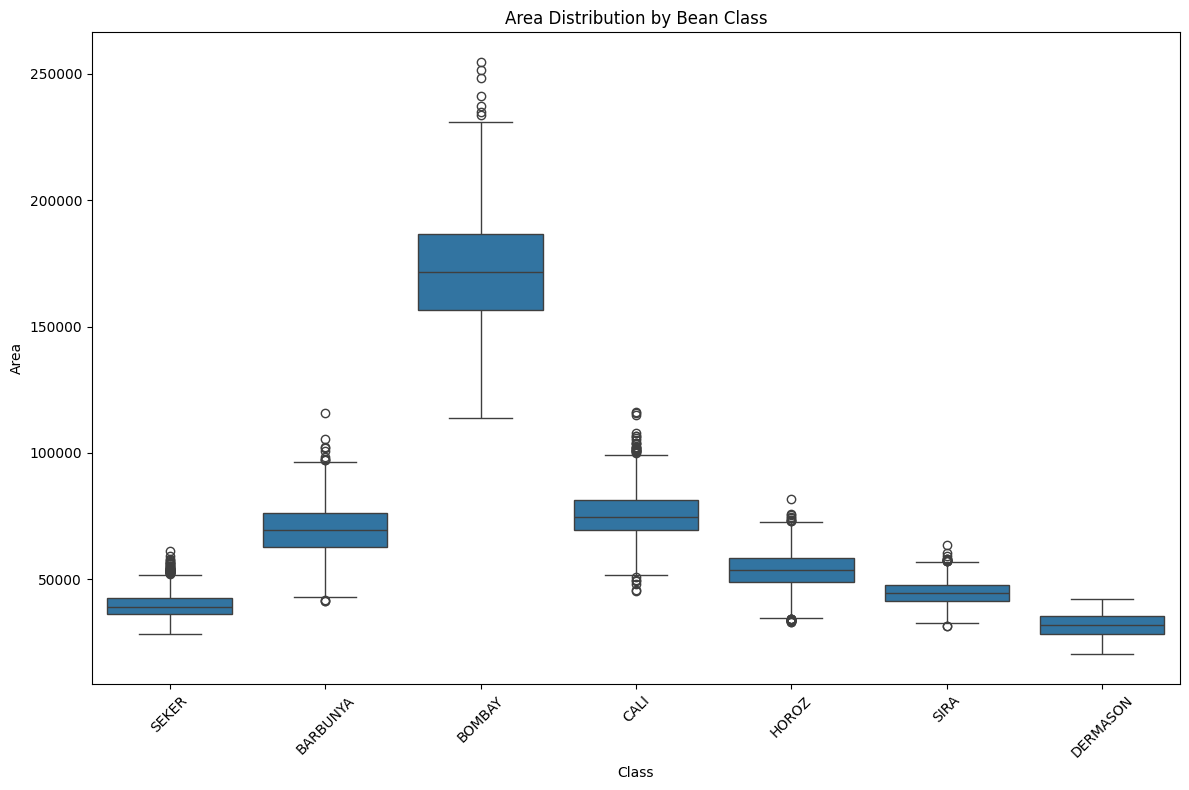

In [6]:
# 5. 주요 피처 시각화 (Box Plot - 면적 분포)
plt.figure(figsize=(12, 8))
sns.boxplot(x='Class', y='Area', data=df)
plt.title('Area Distribution by Bean Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# BOMBAY 품종은 다른 품종에 비해 면적(Area)이 압도적으로 커서 분류가 매우 직관적입니다.

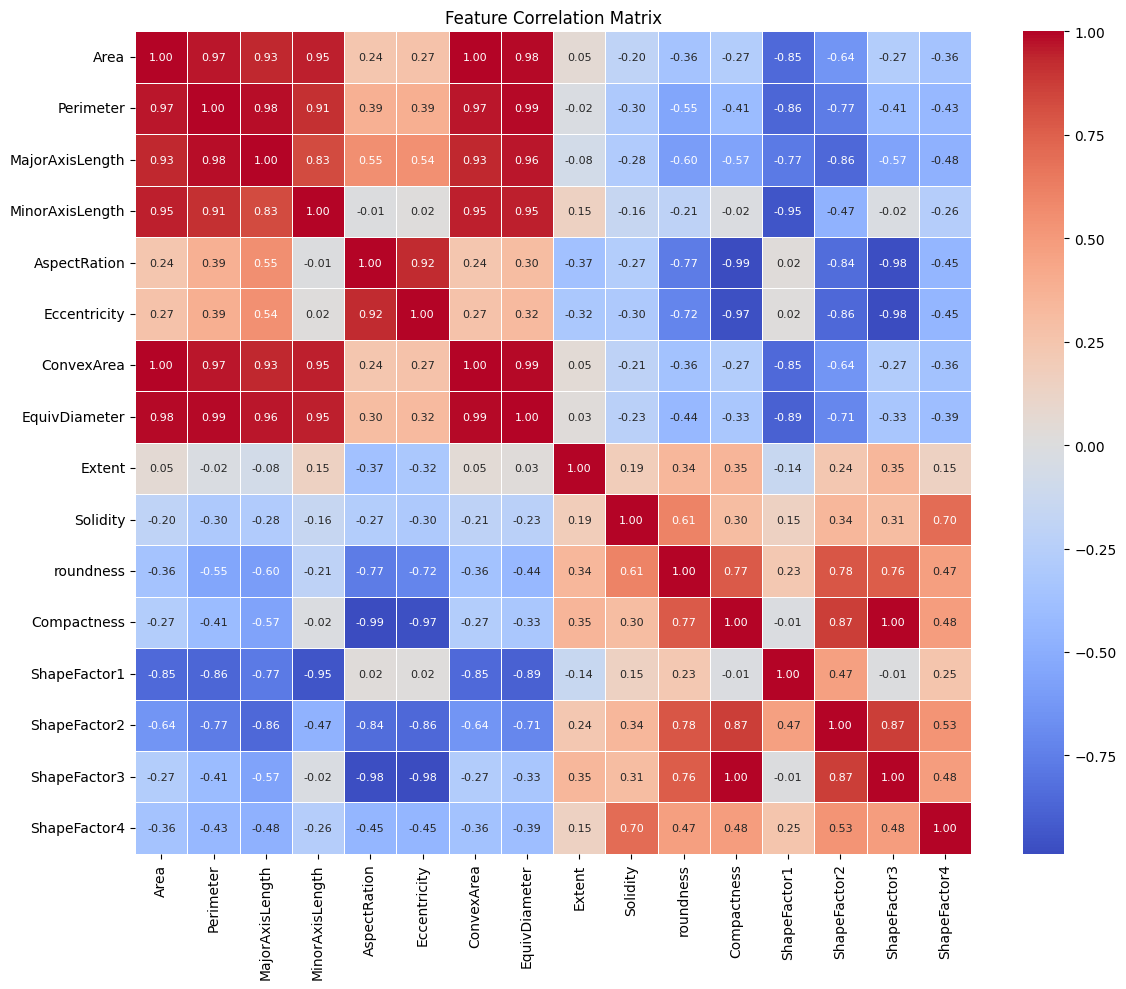

In [ ]:
# 6. 피처 간 상관관계 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt= .2f , cmap='coolwarm', linewidths=0.5, annot_kws={ size : 8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# MajorAxisLength 등 크기 관련 피처들이 강한 상관관계(r > 0.95)를 보이고 있습니다

## 7. 머신러닝 데이터 전처리 (Train/Test Split & Scaling)
- 데이터를 8:2 비율로 분리합니다.
- 클래스 비율을 유지하기 위해 `stratify=y`를 사용합니다.
- 모든 피처를 표준화(Standard Scale)하여 서로 다른 크기 단위를 맞춰줍니다.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 피처 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'학습 데이터 세트 크기: {X_train_scaled.shape}')
print(f'테스트 데이터 세트 크기: {X_test_scaled.shape}')


학습 데이터 세트 크기: (10888, 16)
테스트 데이터 세트 크기: (2723, 16)


## 8. 로지스틱 회귀 (Logistic Regression - Baseline)
기본적인 선형 모델을 사용해 품종 분류 기준 모델을 설정합니다.


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train.values.ravel())

y_pred_lr = lr_model.predict(X_test_scaled)
print('=== Logistic Regression Accuracy ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_lr))


=== Logistic Regression Accuracy ===
Accuracy: 0.9214

=== Classification Report ===
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



## 9. 랜덤 포레스트 (Random Forest Classifier)
비선형 문제를 더 강력하게 학습할 수 있는 결정 트리 기반의 앙상블 모델입니다.


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train.values.ravel())

y_pred_rf = rf_model.predict(X_test_scaled)
print('=== Random Forest Accuracy ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_rf))


=== Random Forest Accuracy ===
Accuracy: 0.9207

=== Classification Report ===
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.97      0.95      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



## 10. 혼동 행렬 (Confusion Matrix) 시각화
품종별 오분류 비율을 히트맵으로 시각적으로 확인합니다.


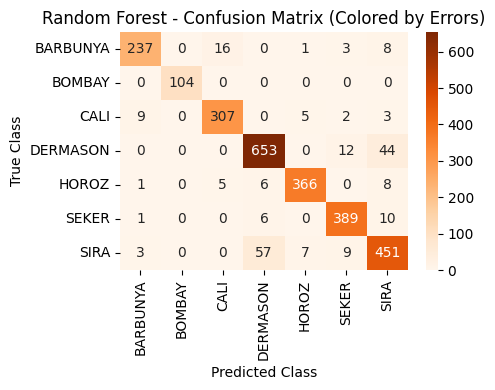

In [17]:
from sklearn.metrics import confusion_matrix
import numpy as np

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=cm, fmt='d', cmap='Oranges', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Random Forest - Confusion Matrix (Colored by Errors)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()


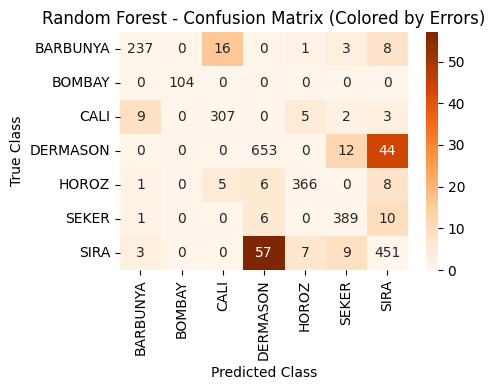

In [18]:
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_rf)

# 대각선(정분류) 값을 0으로 설정하여 오차(틀린 개수)의 크기에 따라서만 색상이 맵핑되도록 합니다.
# 텍스트(annot)에는 원래의 cm 값을 그대로 표시하여 정분류 개수도 함께 볼 수 있습니다.
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

sns.heatmap(cm_errors, annot=cm, fmt='d', cmap='Oranges', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Random Forest - Confusion Matrix (Colored by Errors)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()
